In [1]:
import os
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_ionq import IonQProvider

In [2]:
provider = IonQProvider(token = "MkU7QmnnoPUCcmylhNo9pPgiGqrEJL2E")

/Users/dev/anaconda3/lib/python3.11/site-packages/qiskit_ionq/ionq_backend.py:127: IonQTranspileLevelWarning: Transpiler default optimization_level=2. IonQ (QIS) recommends 0-1 to avoid aggressive re-synthesis; use transpile(..., optimization_level=1).
  warn_bad_transpile_level()


In [4]:
noisy_backend = provider.get_backend("ionq_simulator")
noisy_backend.set_options(noise_model="aria-1")

In [5]:
dev = qml.device('qiskit.remote', wires=1, backend=noisy_backend)
@qml.set_shots(2000)
@qml.qnode(dev, diff_method="parameter-shift")
def circuit(x, params):
  qml.RY(x, wires=0)
  qml.Rot(params[0], params[1], params[2], wires=0)

  return qml.expval(qml.PauliZ(0))


(<Figure size 500x200 with 1 Axes>, <Axes: >)

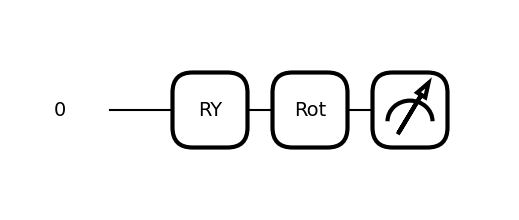

In [6]:
qml.draw_mpl(circuit)(0,[0.0, 0.0, 0.0])

In [7]:
def loss(Y, predictions):
  total_loss = 0
  for y,p in zip(Y, predictions):
    total_loss += (y-p)**2

  return total_loss


def cost(X, params):
  predictions = [ circuit(x, params) for x in X]
  Y = np.sin(X)
  cost = loss(Y, predictions)
  return cost

In [8]:
X = np.linspace(0, 2*np.pi, 10)
X.requires_grad = False
X_test = np.linspace(0 +0.2, 2*np.pi+0.2, 10)

In [ ]:
import csv

opt = qml.GradientDescentOptimizer(stepsize=0.1)
params = np.array([0.1, 0.1, 0.1], requires_grad=True)
n_iter = 100

log_file = "training_log.csv"

# write header once
with open(log_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["iteration", "cost", "param_0", "param_1", "param_2"])

for it in range(n_iter):
    X_and_params, prev_cost = opt.step_and_cost(cost, X, params)
    params = X_and_params[1]

    current_cost = cost(X, params)

    # append row
    with open(log_file, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([it, float(current_cost), *params.tolist()])

    if it % 10 == 0:
        print(f"Step: {it}, Cost: {current_cost}")
